In [2]:
import earthaccess
import pyarrow.parquet as pq
import datetime
import matplotlib.pyplot as plt
import cartopy
import xarray as xr
import numpy as np
import pandas as pd
import statsmodels.api as sm

# This contains the path to the CrocoLake BGC-Argo dataset
# Update this file path if using a local copy
from setup import parquet_dir

# PACE match-up functions
from pace_matchup_fxns import get_sat_ts_matchups

# Get BGC-Argo matchups in the North Atlantic

## 1. Get BGC-Argo data in the North Atlantic

Here we will use the BGC-Argo CrocoLake data product to get all profiles in the North Atlantic in the last 180 days. Below we specify the time, space, and depth thresholds for our search. In this example, we will be looking at the surface data only (<10 dbar).

In [3]:
# Time filter
# time1 = datetime.datetime.now()
time1 = datetime.datetime.strptime('2026-08-17', "%Y-%m-%d")
time0 = time1 - datetime.timedelta(days=180)

# Region filter
lat0 = 45
lat1 = 70
lon0 = -85
lon1 = 0

# Depth filter: Only want "surface" values
depth_min = 10

Subset the BGC-Argo dataset based on these thresholds and load the data into a pandas DataFrame

In [4]:
# Setting up parquet schema
BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")

filter_coords_time = [
    ("JULD",">=",time0),
    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
    ("PRES", "<", depth_min),
]

df = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filter_coords_time)
df = df.read().to_pandas()
df

,PLATFORM_NUMBER,N_PROF,N_LEVELS,CYCLE_NUMBER,DIRECTION,DATE_UPDATE,LATITUDE,LONGITUDE,POSITION_QC,JULD,...,UP_IRRADIANCE555_ADJUSTED_QC,UP_IRRADIANCE555_ADJUSTED_ERROR,UP_IRRADIANCE555_DATA_MODE,DOWNWELLING_PAR,DOWNWELLING_PAR_QC,DOWNWELLING_PAR_dPRES,DOWNWELLING_PAR_ADJUSTED,DOWNWELLING_PAR_ADJUSTED_QC,DOWNWELLING_PAR_ADJUSTED_ERROR,DOWNWELLING_PAR_DATA_MODE
0,3901580,127,0,118,A,2026-08-04 21:06:58,54.67578,-19.432610,1,2026-02-25 05:16:00.000000000,...,<NA>,NaN,,0.006361,2,0.0,NaN,0,NaN,R
1,3901580,127,1,118,A,2026-08-04 21:06:58,54.67578,-19.432610,1,2026-02-25 05:16:00.000000000,...,<NA>,NaN,,0.005584,8,0.1,NaN,0,NaN,R
2,3901580,127,2,118,A,2026-08-04 21:06:58,54.67578,-19.432610,1,2026-02-25 05:16:00.000000000,...,<NA>,NaN,,0.004806,2,0.0,NaN,0,NaN,R
3,3901580,127,3,118,A,2026-08-04 21:06:58,54.67578,-19.432610,1,2026-02-25 05:16:00.000000000,...,<NA>,NaN,,-0.004495,2,0.0,NaN,0,NaN,R
4,3901580,127,4,118,A,2026-08-04 21:06:58,54.67578,-19.432610,1,2026-02-25 05:16:00.000000000,...,<NA>,NaN,,NaN,0,NaN,NaN,0,NaN,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56564,2901984,152,17,153,A,2026-08-10 05:07:25,50.47886,-48.188728,1,2026-08-10 00:47:44.984011776,...,<NA>,NaN,,NaN,<NA>,NaN,NaN,<NA>,NaN,
56565,2901984,152,18,153,A,2026-08-10 05:07:25,50.47886,-48.188728,1,2026-08-10 00:47:44.984011776,...,<NA>,NaN,,NaN,<NA>,NaN,NaN,<NA>,NaN,
56566,2901984,152,19,153,A,2026-08-10 05:07:25,50.47886,-48.188728,1,2026-08-10 00:47:44.984011776,...,<NA>,NaN,,NaN,<NA>,NaN,NaN,<NA>,NaN,
56567,2901984,152,20,153,A,2026-08-10 05:07:25,50.47886,-48.188728,1,2026-08-10 00:47:44.984011776,...,<NA>,NaN,,NaN,<NA>,NaN,NaN,<NA>,NaN,


For this example, we are interested in looking at the median surface chlorophyll (CHLA) and particulate backscatter (BBP700) data for each profile. We are computing a median because we did not de-spike the bio-optical data. For our region and date range, we have 718 profiles.

In [5]:
variable_list = ['BBP700','BBP700_QC',  'CHLA','CHLA_QC',
                 'CYCLE_NUMBER',
                 'DOXY','DOXY_QC',
                 'JULD','LATITUDE','LONGITUDE',
                 'PLATFORM_NUMBER','PRES',
                 'PSAL','PSAL_QC',
                 'TEMP', 'TEMP_QC',]

# Calculate the median surface values
surface_float = df.loc[:, variable_list].groupby(by = ['PLATFORM_NUMBER','CYCLE_NUMBER']).median()

# Get all non-NA surface bbp and chla
float_data = surface_float.loc[(surface_float.loc[:,'BBP700'].isna() == False) | \
    (surface_float.loc[:,'CHLA'].isna() == False),:]
float_data

BBP700  BBP700_QC      CHLA  CHLA_QC  \
PLATFORM_NUMBER CYCLE_NUMBER                                           
1902602         202           0.000361        1.0  0.324000      3.0   
                203           0.000425        1.0  0.188640      3.0   
                204           0.000428        1.0  0.194400      3.0   
                205           0.000459        1.0  0.355500      3.0   
                206           0.000483        1.0  0.158400      3.0   
...                                ...        ...       ...      ...   
7902223         76            0.006875        1.0  0.187026      3.0   
                77            0.006555        1.0  0.178850      3.0   
                78            0.003403        1.0  0.635100      3.0   
                79            0.002291        1.0  0.277400      3.0   
                80            0.003559        1.0  1.812931      3.0   

                                    DOXY  DOXY_QC  \
PLATFORM_NUMBER CYCLE_NUMBER                        
1902602         202           294.761810      0.0   
                203           291.245178      0.0   
                204           293.224457      0.0   
                205           293.753265      0.0   
                206           295.209106      0.0   
...                                  ...      ...   
7902223         76            281.041443      0.0   
                77            275.165619      0.0   
                78            269.723877      0.0   
                79            266.637146      0.0   
                80            279.548309      0.0   

                                                      JULD   LATITUDE  \
PLATFORM_NUMBER CYCLE_NUMBER                                            
1902602         202          2026-02-18 11:24:00.000000000  64.818238   
                203          2026-02-23 11:26:00.000000000  64.849960   
                204          2026-02-28 11:29:00.000000000  64.780737   
                205          2026-03-05 11:24:00.000000000  64.762023   
                206          2026-03-10 11:27:00.000000000  64.697158   
...                                                    ...        ...   
7902223         76           2026-06-24 11:35:28.993182208  61.968982   
                77           2026-07-04 11:39:28.993177600  62.102894   
                78           2026-07-14 11:37:28.993028096  62.048774   
                79           2026-07-24 11:37:28.993169408  61.991221   
                80           2026-08-03 11:37:28.993169408  62.221082   

                              LONGITUDE   PRES       PSAL  PSAL_QC       TEMP  \
PLATFORM_NUMBER CYCLE_NUMBER                                                    
1902602         202           -4.468215  5.420  34.842999      8.0   3.631000   
                203           -4.526968  4.060  34.890038      8.0   4.042460   
                204           -4.628260  4.400  34.875999      8.0   3.762000   
                205           -4.598490  4.150  34.866642      8.0   3.852612   
                206           -4.684060  3.620  34.876999      8.0   3.774000   
...                                 ...    ...        ...      ...        ...   
7902223         76           -31.927754  3.490  35.120907      3.0   9.255500   
                77           -32.191692  4.032  35.164497      3.0   9.610554   
                78           -31.599922  4.350  35.069557      8.0   9.775581   
                79           -31.196450  4.490  35.098999      8.0  10.244720   
                80           -30.746697  4.932  35.089352      5.5  11.457327   

                              TEMP_QC  
PLATFORM_NUMBER CYCLE_NUMBER           
1902602         202               8.0  
                203               8.0  
                204               8.0  
                205               8.0  
                206               8.0  
...                               ...  
7902223         76                8.0  
                77                8.0  
 

## 2. Let's visualize the BGC-Argo data

Here we can plot the surface values to see the spatial coverage in our region.

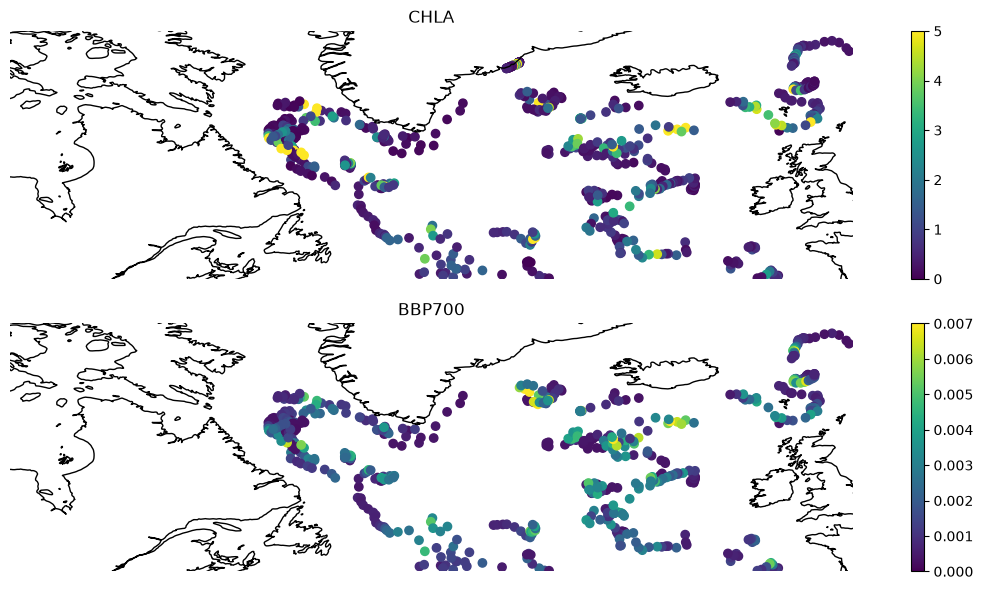

In [7]:
proj = cartopy.crs.PlateCarree()
fig = plt.figure(figsize=(12, 6), )
rr = 2; cc = 1

lims = [[0,5],[0,7e-3]]
for pi, param in enumerate(['CHLA','BBP700']):
    
    ax = fig.add_subplot(rr, cc, int(pi+1), projection=proj, frameon=False)
    
    pcm = ax.scatter(float_data.loc[:,'LONGITUDE'], float_data.loc[:,'LATITUDE'], 
                c = float_data.loc[:,param], vmin = lims[pi][0], vmax = lims[pi][1])
    cbar = fig.colorbar(pcm, ax=ax)
    
    ax.add_feature(cartopy.feature.COASTLINE)

    ax.set_extent([lon0,lon1, lat0,lat1], crs = proj)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax.set_title(param)


fig.tight_layout()

## 3. Using Earthaccess to download NASA Ocean Color data

- To use [earthaccess](https://earthaccess.readthedocs.io/en/stable/), you need to have a [NASA Earthdata Login](https://urs.earthdata.nasa.gov/)
- Need to provide username and passwork as a [.netrc](https://nsidc.org/data/user-resources/help-center/creating-netrc-file-earthdata-login) file saved in your JupyterHub directory (or on personal device) or as environmental variables.
- Need to run earthaccess.login() at the start of every session

In [11]:
earthaccess.login();

**Satellite: ocean color instrument**
- PACE: OCI (Ocean Color Instrument)
- Aqua: MODIS (Moderate Resolution Imaging Spectroradiometer) 

In [12]:
results = earthaccess.search_datasets(instrument="oci")

for item in results:
    summary = item.summary()
    print(summary["short-name"])

PACE_OCI_MI_CLOSE
PACE_OCI_L0_SCI
PACE_OCI_L1A_SCI
PACE_OCI_L1B_CLOSE
PACE_OCI_L1B_SCI
PACE_OCI_L1C_SCI
PACE_OCI_L2_UVAI_UAA_NRT
PACE_OCI_L2_UVAI_UAA
PACE_OCI_L2_AER_UAA_NRT
PACE_OCI_L2_AER_UAA
PACE_OCI_L2_AOP_NRT
PACE_OCI_L2_AOP
PACE_OCI_L2_CLOSE
PACE_OCI_L2_CLOUD_MASK_NRT
PACE_OCI_L2_CLOUD_MASK
PACE_OCI_L2_CLOUD_NRT
PACE_OCI_L2_CLOUD
PACE_OCI_L2_LANDVI_NRT
PACE_OCI_L2_LANDVI
PACE_OCI_L2_BGC_NRT
PACE_OCI_L2_BGC
PACE_OCI_L2_IOP_NRT
PACE_OCI_L2_IOP
PACE_OCI_L2_PAR_NRT
PACE_OCI_L2_PAR
PACE_OCI_L2_SFREFL_NRT
PACE_OCI_L2_SFREFL
PACE_OCI_L2_TRGAS_NRT
PACE_OCI_L2_TRGAS
PACE_OCI_L3B_CLOSE
PACE_OCI_L3B_KD_NRT
PACE_OCI_L3B_LANDVI_NRT
PACE_OCI_L3B_LANDVI
PACE_OCI_L3B_IOP_NRT
PACE_OCI_L3B_PAR_NRT
PACE_OCI_L3B_SFREFL_NRT
PACE_OCI_L3B_SFREFL
PACE_OCI_L3M_UVAI_UAA_NRT
PACE_OCI_L3M_UVAI_UAA
PACE_OCI_L3M_AER_UAA_NRT
PACE_OCI_L3M_AER_UAA
PACE_OCI_L3M_AOP_NRT
PACE_OCI_L3M_AOP
PACE_OCI_L3M_CLOSE
PACE_OCI_L3M_CLOUD_MASK_NRT
PACE_OCI_L3M_CLOUD_MASK
PACE_OCI_L3M_CLOUD_NRT
PACE_OCI_L3M_CLOUD
PACE_OCI_L3M_KD_

/tmp/ipykernel_237/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/tmp/ipykernel_237/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/tmp/ipykernel_237/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/tmp/ipykernel_237/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/tmp/ipykernel_237/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will 

We can use the earthaccess search_data to get all data files based on time, space, and also cloud fraction. Let's refine our search to our specified region and date range. In this example, we will look at the biogeochemical (BGC) data, which provides surface chlorophyll-a, particulate organic and inorganic carbon, and phytoplankton carbon. This is a provisional product. For more information on these PACE data products, please visit this [site](https://pace.oceansciences.org/data_table.htm).

In [13]:
short_name = 'PACE_OCI_L2_BGC'

tspan = (time0.strftime('%Y-%m-%d'), time1.strftime('%Y-%m-%d'))
bbox = (lon0, lat0, lon1, lat1)
clouds = (0, 50)

results = earthaccess.search_data(
    short_name = short_name,
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)
len(results)

/opt/conda/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


62

Using our search, lets get the filepaths we can use to access these files.

In [14]:
paths = earthaccess.open(results)

/opt/conda/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/62 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/62 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/62 [00:00<?, ?it/s]

We can use xarray to open these datafiles. However, if we open one of these files using open_dataset, we see that there are no data variables, only attributes. This is because these files are have a hierarchical format.

In [15]:
fi = 15
dataset = xr.open_dataset(paths[fi])
dataset

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/47)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20260224T112610.L2.OC_BGC.V3_...
    processing_version:                3.2
    history:                           l2gen par=/data2/sdpsoper/vdc/vpu28/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -5.500987
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0210314989089966
    geospatial_bounds:                 POLYGON((3.88261 28.76806,31.60477 34....

We can, however, open these files using open_dataset if we specify the group.

In [16]:
dataset = xr.open_dataset(paths[fi], group="geophysical_data")
dataset

<xarray.Dataset> Size: 61MB
Dimensions:           (number_of_lines: 1710, pixels_per_line: 1272)
Dimensions without coordinates: number_of_lines, pixels_per_line
Data variables:
    chlor_a           (number_of_lines, pixels_per_line) float32 9MB ...
    carbon_phyto      (number_of_lines, pixels_per_line) float32 9MB ...
    pic               (number_of_lines, pixels_per_line) float32 9MB ...
    poc               (number_of_lines, pixels_per_line) float32 9MB ...
    chlor_a_unc       (number_of_lines, pixels_per_line) float32 9MB ...
    carbon_phyto_unc  (number_of_lines, pixels_per_line) float32 9MB ...
    l2_flags          (number_of_lines, pixels_per_line) int32 9MB ...

We can use open_datatree to merge all of these groups into one dataset, which is easier to use

In [17]:
datatree = xr.open_datatree(paths[fi])
dataset = xr.merge(datatree.to_dict().values())
dataset

/tmp/ipykernel_237/177299127.py:1: FutureWarning: In a future version, xarray will not decode the variable 'day' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  datatree = xr.open_datatree(paths[fi])
/tmp/ipykernel_237/177299127.py:1: FutureWarning: In a future version, xarray will not decode the variable 'msec' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decodi

<xarray.Dataset> Size: 78MB
Dimensions:           (wavelength: 286, number_of_reflective_bands: 286,
                       number_of_lines: 1710, pixels_per_line: 1272)
Coordinates:
  * wavelength        (wavelength) float64 2kB 315.0 316.0 ... 2.258e+03
Dimensions without coordinates: number_of_reflective_bands, number_of_lines,
                                pixels_per_line
Data variables: (12/32)
    fwave             (wavelength) float32 1kB ...
    vcal_gain         (number_of_reflective_bands) float32 1kB ...
    vcal_offset       (number_of_reflective_bands) float32 1kB ...
    F0                (number_of_reflective_bands) float32 1kB ...
    aw                (number_of_reflective_bands) float32 1kB ...
    bbw               (number_of_reflective_bands) float32 1kB ...
    ...                ...
    chlor_a_unc       (number_of_lines, pixels_per_line) float32 9MB ...
    carbon_phyto_unc  (number_of_lines, pixels_per_line) float32 9MB ...
    l2_flags          (number_of_lines, pixels_per_line) int32 9MB ...
    longitude         (number_of_lines, pixels_per_line) float32 9MB ...
    latitude          (number_of_lines, pixels_per_line) float32 9MB ...
    tilt              (number_of_lines) float32 7kB ...
Attributes: (12/47)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20260224T112610.L2.OC_BGC.V3_...
    processing_version:                3.2
    history:                           l2gen par=/data2/sdpsoper/vdc/vpu28/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -5.500987
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0210314989089966
    geospatial_bounds:                 POLYGON((3.88261 28.76806,31.60477 34....

Let's visualize one of these datafiles/granules

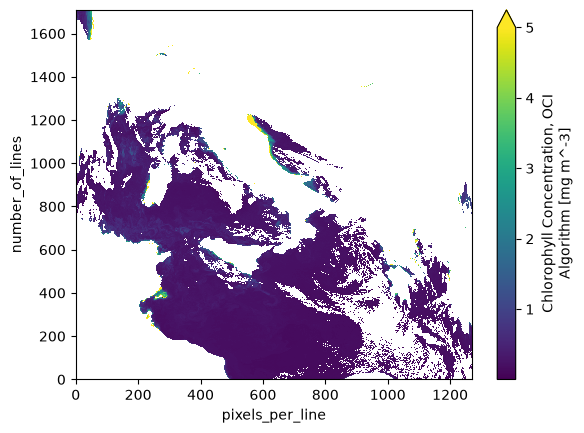

In [19]:
artist = dataset["chlor_a"].plot(vmax = 5)

## 3. Matchup float profiles to NASA PACE BGC data

The following code has been modified from [PACE Hackweek tutorials](https://pacehackweek.github.io/pace-2025/presentations/notebooks/satellite_insitu_matchups.html) to be more generalized (from L2 AOP/Rrs to include L2 BGC, etc.). However, you can further modify these codes to better fit your interests. \ 
\
In this example, we have 718 profiles, so it takes some time to run these matchups. For this example, we will load results from running this match-up code, based on the 5x5 match-up strategy.

In [23]:
get_sat = False

fname = 'PACE_BGCArgo_matchup_example.csv'
if get_sat:
    all_sat = FloatMatchup(float_data, "PACE_BGC", hour_window = 12, save = True, savename = fname)

else:
    all_sat = pd.read_csv(fname)

all_sat

,Unnamed: 0,sat_datetime,sat_cv,sat_latitude,sat_longitude,sat_pixel_valid,sat_chlor_a,sat_carbon_phyto,sat_pic,sat_poc,sat_chlor_a_unc,sat_carbon_phyto_unc,PLATFORM_NUMBER,CYCLE_NUMBER
0,0,2026-02-18 09:44:55+00:00,NaN,64.842470,-4.464646,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1902602,202
1,1,2026-02-18 11:23:14+00:00,NaN,64.817410,-4.466867,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1902602,202
2,2,2026-02-18 12:56:34+00:00,NaN,64.812430,-4.470133,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1902602,202
3,3,2026-02-28 10:34:13+00:00,NaN,64.468124,-4.515563,15.0,1.046215,20.890442,0.000015,197.199951,0.274797,4.229245,1902602,204
4,4,2026-02-28 12:12:33+00:00,NaN,64.775960,-4.630725,25.0,0.405483,11.735717,0.000026,100.830681,0.046431,1.622917,1902602,204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1037,1037,2026-05-15 13:42:35+00:00,NaN,62.472160,-30.287832,4.0,0.180953,36.304729,0.000136,68.600098,0.018106,2.095977,7902223,72
1038,1038,2026-05-15 15:15:54+00:00,NaN,62.468395,-30.260357,0.0,NaN,NaN,NaN,NaN,NaN,NaN,7902223,72
1039,1039,2026-05-25 04:55:55+00:00,NaN,62.283764,-30.647423,25.0,NaN,NaN,NaN,NaN,NaN,NaN,7902223,73
1040,1040,2026-05-25 12:57:31+00:00,NaN,62.281110,-30.635925,1.0,1.520019,54.762047,0.000130,254.600098,0.388026,6.913980,7902223,73


## 4. Visualize match up results

Here, we want to compare surface BGC-Argo chlorophyll and POC to the same values from PACE. To get BGC-Argo POC, we will convert the BBP700 data into POC using Cetinic et al., 2012.

In [25]:
def bbp_poc(bbp, method='C12'):

    if method == 'C12':
        poc = 35422*bbp + (- 14.4)

    return poc

Based on all of the satellite data, match-up the corresponding float values and compute POC

In [31]:
valid_matchup = all_sat.loc[all_sat.loc[:,'sat_pixel_valid']>0,:]

float_matchup = np.zeros((valid_matchup.shape[0], 2))*np.nan

for i in np.arange(valid_matchup.shape[0]):

    wmo, profnum = valid_matchup.loc[:,['PLATFORM_NUMBER','CYCLE_NUMBER']].values[i,:]

    valid_float = float_data.loc[(wmo, profnum),:]
    valid_float = pd.to_numeric(valid_float, errors='coerce')
    
    float_matchup[i, 0] = valid_float.loc['CHLA']
    float_matchup[i, 1] = valid_float.loc['BBP700']

valid_matchup = valid_matchup.assign(float_chlor_a = float_matchup[:, 0])
valid_matchup = valid_matchup.assign(float_bbp700 = float_matchup[:, 1])
valid_matchup = valid_matchup.assign(float_poc = bbp_poc(float_matchup[:,1]))
valid_matchup

,Unnamed: 0,sat_datetime,sat_cv,sat_latitude,sat_longitude,sat_pixel_valid,sat_chlor_a,sat_carbon_phyto,sat_pic,sat_poc,sat_chlor_a_unc,sat_carbon_phyto_unc,PLATFORM_NUMBER,CYCLE_NUMBER,float_chlor_a,float_bbp700,float_poc
3,3,2026-02-28 10:34:13+00:00,NaN,64.468124,-4.515563,15.0,1.046215,20.890442,0.000015,197.199951,0.274797,4.229245,1902602,204,0.194400,0.000428,0.766424
4,4,2026-02-28 12:12:33+00:00,NaN,64.775960,-4.630725,25.0,0.405483,11.735717,0.000026,100.830681,0.046431,1.622917,1902602,204,0.194400,0.000428,0.766424
22,22,2026-04-09 10:53:56+00:00,NaN,64.463790,-4.934859,21.0,0.271175,13.337291,0.000038,73.899940,0.030300,1.146601,1902602,212,0.244800,0.000702,10.475081
23,23,2026-04-09 12:27:15+00:00,NaN,64.448440,-4.946501,13.0,0.266939,21.294029,0.000058,77.666557,0.031132,1.519027,1902602,212,0.244800,0.000702,10.475081
24,24,2026-04-14 10:31:37+00:00,NaN,64.373955,-5.136390,18.0,NaN,NaN,NaN,NaN,NaN,NaN,1902602,213,0.302400,0.000946,19.113263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011,1011,2026-05-28 12:58:37+00:00,NaN,60.815070,-4.254339,25.0,2.045424,41.650795,0.000072,310.352844,0.277309,3.421228,7902203,147,5.874018,0.004028,128.268103
1037,1037,2026-05-15 13:42:35+00:00,NaN,62.472160,-30.287832,4.0,0.180953,36.304729,0.000136,68.600098,0.018106,2.095977,7902223,72,0.307476,0.001302,31.704694
1039,1039,2026-05-25 04:55:55+00:00,NaN,62.283764,-30.647423,25.0,NaN,NaN,NaN,NaN,NaN,NaN,7902223,73,4.524248,0.006507,216.089237
1040,1040,2026-05-25 12:57:31+00:00,NaN,62.281110,-30.635925,1.0,1.520019,54.762047,0.000130,254.600098,0.388026,6.913980,7902223,73,4.524248,0.006507,216.089237


Now, we can compare the float and satellite results!

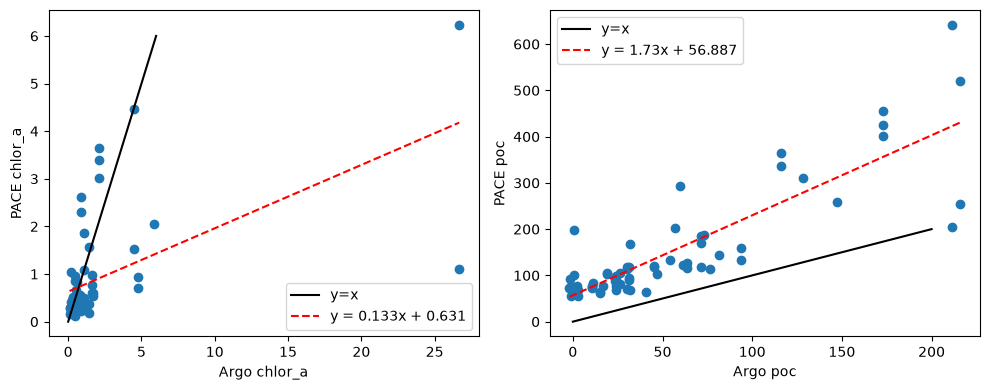

In [32]:
fig = plt.figure(figsize = (10, 4))
rr = 1; cc = 2

param_list = ['chlor_a','poc']

yy = [[0, 6],[0,200]]
for i, param in enumerate(param_list):

    ax = fig.add_subplot(rr, cc, int(i+1))

    y = valid_matchup.loc[:,'sat_'+param].values
    x = valid_matchup.loc[:,'float_'+param].values

    inds = np.where((np.isnan(x)==False) & (np.isnan(y)==False))
    x = x[inds]; y = y[inds]
    x_range = np.linspace(np.nanmin(x), np.nanmax(x))
    
    model = sm.OLS(y, sm.add_constant(x)).fit()
    eqn = 'y = '+str(np.round(model.params[1],3))+'x + '+str(np.round(model.params[0],3))
    
    ax.scatter(x, y)
    ax.plot(yy[i], yy[i], 'k-',label = 'y=x')
    ax.plot(x_range, model.predict(sm.add_constant(x_range)), 'r--', label=eqn)
    ax.legend()

    ax.set_xlabel('Argo '+param)
    ax.set_ylabel('PACE '+param)


fig.tight_layout()

And we can also compare these results with time!

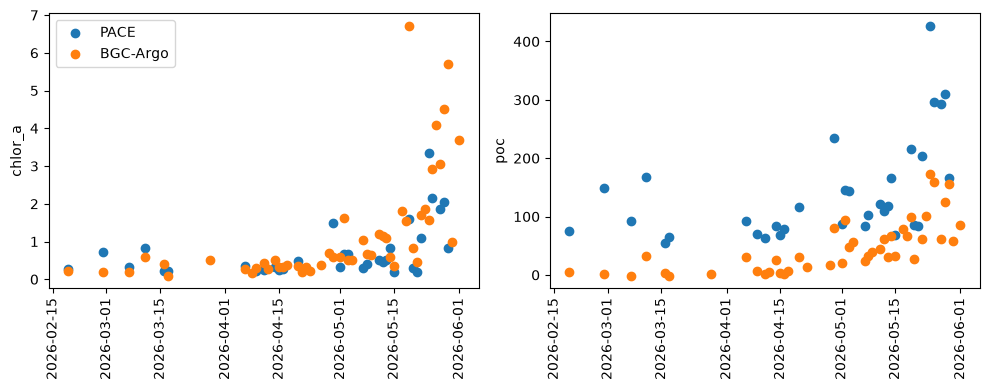

In [42]:
valid_matchup = valid_matchup.assign(JULD = [pd.Timestamp(xi).date() for xi in valid_matchup.loc[:,'sat_datetime'].values])

fig  = plt.figure(figsize = (10,4))
rr = 1; cc = 2
bgclist = ['chlor_a','poc']

for pi, param in enumerate(bgclist):

    ax = fig.add_subplot(rr,cc,int(pi+1))
    
    param_list = ['JULD','sat_'+param,'float_'+param]
    x = valid_matchup.loc[:,param_list].groupby('JULD').mean().index.values
    
    ax.scatter(x, valid_matchup.loc[:,param_list].groupby('JULD').mean().loc[:,'sat_'+param], label = 'PACE')
    ax.scatter(x, valid_matchup.loc[:,param_list].groupby('JULD').mean().loc[:,'float_'+param], label = 'BGC-Argo')

    ax.set_ylabel(param)
    ax.tick_params(axis='x', labelrotation=90)

    if pi == 0:
        ax.legend()
fig.tight_layout()